In [1]:
import os
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from esem.utils import get_random_params

import above_library.plotting as plotting
import above_library.parameter_generation as paramgen
import above_library.emulation as em
import above_library.processing as proc
import above_library.utils as utils

import importlib

2026-05-26 10:18:20.111764: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-26 10:18:20.155401: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-26 10:18:23.342068: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/glade/work/afoster/conda-envs/above/lib/python3.12/site-packages/esem/__init__.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated fo

In [2]:
top_dir = '/glade/work/afoster/ABoVE/'
hist_dir = os.path.join(top_dir, 'hist_outputs')
obs_dir = os.path.join(top_dir, 'obs_data')
fig_dir = os.path.join(top_dir, 'figures')
emulator_dir = os.path.join(top_dir, 'emulators')

param_dir = '/glade/work/afoster/ABoVE/parameter_files'
lh_dir = os.path.join(param_dir, 'fates_lh_black_spruce')
lh_key_file = os.path.join(lh_dir, 'nwt_lh_key_jags.csv')

var_config_file = '/glade/work/afoster/ABoVE/model_vars.yaml'
var_config = utils.get_config_file(var_config_file)

ensemble_tag = 'NWT_LH_'

site = 'ZF14-207'
pft = 'black_spruce'
stand_age = 100
latitude = 62.43462
longitude = 246.84602

start_year = stand_age - 10 + 1

In [3]:
obs_dat = pd.read_csv(os.path.join(obs_dir, 'site_averages.csv'), index_col=[0])
stand_structure = pd.read_csv(os.path.join(obs_dir, 'site_structure.csv'), index_col=[0])
height_averages = pd.read_csv(os.path.join(obs_dir, 'height_averages.csv'), index_col=[0])
compiled_sites = pd.read_csv(os.path.join(obs_dir, 'compiled_sites.csv'), index_col=[0])

In [4]:
model_dat = xr.open_dataset(os.path.join(hist_dir, 'black_spruce_ens.nc'))

In [5]:
lh_key = em.get_lh_key(lh_key_file, ensemble_tag,
                       np.unique(model_dat.ensemble.values))
param_names = lh_key.columns

In [6]:
lh_key = pd.read_csv(lh_key_file, index_col=[0])
lh_key = lh_key.drop(columns=['ensemble'])
param_names = lh_key.columns

lh_key_plotting = lh_key.copy()
lh_key_plotting['ensemble'] = np.arange(0, 600)

In [7]:
emulation_ds = proc.get_ensemble_ds(model_dat)
ensemble_ids = emulation_ds.ensemble.values

In [8]:
obs_ds = proc.get_obs_ds(obs_dat, stand_structure, height_averages, compiled_sites, pft, site)

## Investigate Ensemble

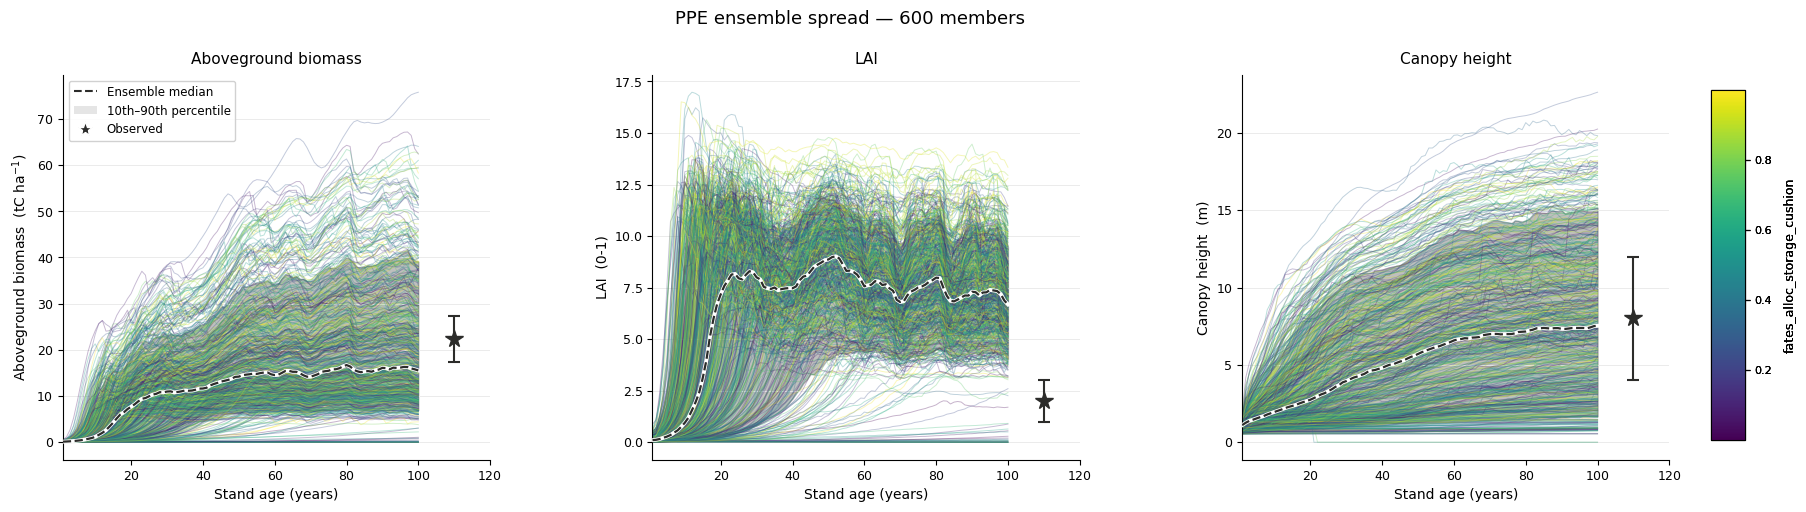

In [15]:
variables = ['biomass', 'LAI', 'height']
years = []
data_arrays = []
obs_vals = []
obs_uncs = []
obs_ages = []
for variable in variables:
    yrs, data = proc.get_var(emulation_ds, variable)
    obs_vals.append(obs_ds.sel(type='mean')[variable])
    obs_uncs.append(obs_ds.sel(type='std')[variable])
    obs_ages.append(110)
    years.append(yrs)
    data_arrays.append(data)

i = 0
color_param = param_names[i]
color_label = param_names[i]
plotting.plot_spaghetti_ensemble(variables, years, data_arrays, ensemble_ids,
                                 obs_vals, obs_ages, obs_uncs, lh_key_plotting,
                                 var_config, color_param, color_label)
plt.savefig(os.path.join(fig_dir, "ppe_spread.png"),
            dpi=200, bbox_inches="tight")

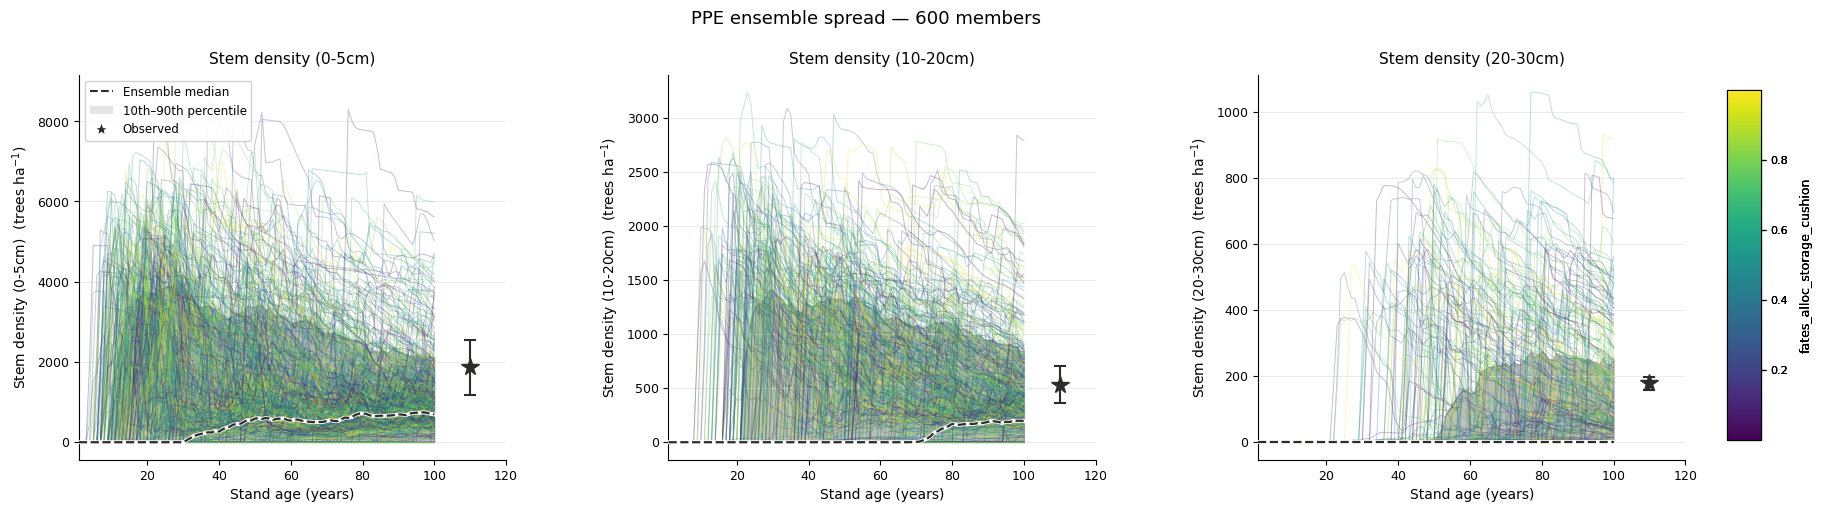

In [14]:
variables = ['tree_dens_small', 'tree_dens_med', 'tree_dens_large']
years = []
data_arrays = []
obs_vals = []
obs_uncs = []
obs_ages = []
for variable in variables:
    yrs, data = proc.get_var(emulation_ds, variable)
    obs_vals.append(obs_ds.sel(type='mean')[variable])
    obs_uncs.append(obs_ds.sel(type='std')[variable])
    obs_ages.append(110)
    years.append(yrs)
    data_arrays.append(data)

i = 0
color_param = param_names[i]
color_label = param_names[i]
plotting.plot_spaghetti_ensemble(variables, years, data_arrays, ensemble_ids,
                                 obs_vals, obs_ages, obs_uncs, lh_key_plotting,
                                 var_config, color_param, color_label)
plt.savefig(os.path.join(fig_dir, "ppe_spread_density.png"),
            dpi=200, bbox_inches="tight")

## Emulation

### Train Emulators

In [ ]:
if False:
    variables = list(emulation_ds.data_vars)
    for variable in variables:
        
        emulator_name = f"{pft}_{variable}"
        model_vals = emulation_ds[variable].sel(year=slice(start_year, stand_age)).mean(dim='year').values
        
        if variable in log_vars:
            model_vals = np.log(model_vals + 1.0)
        r2, rmse, em_sd = em.create_emulator(
            model_vals, emulator_name, lh_key, emulator_dir, var_config, pft
        )

### Test Emulators

In [16]:
variables = ['basal_area', 'height', 'biomass', 'LAI']
actuals, pred_means, pred_stds = em.get_predicted_actuals(variables,
                                                          emulation_ds,
                                                          start_year,
                                                          stand_age,
                                                          lh_key, pft,
                                                          emulator_dir)

2026-05-26 10:22:54.131623: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:282] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


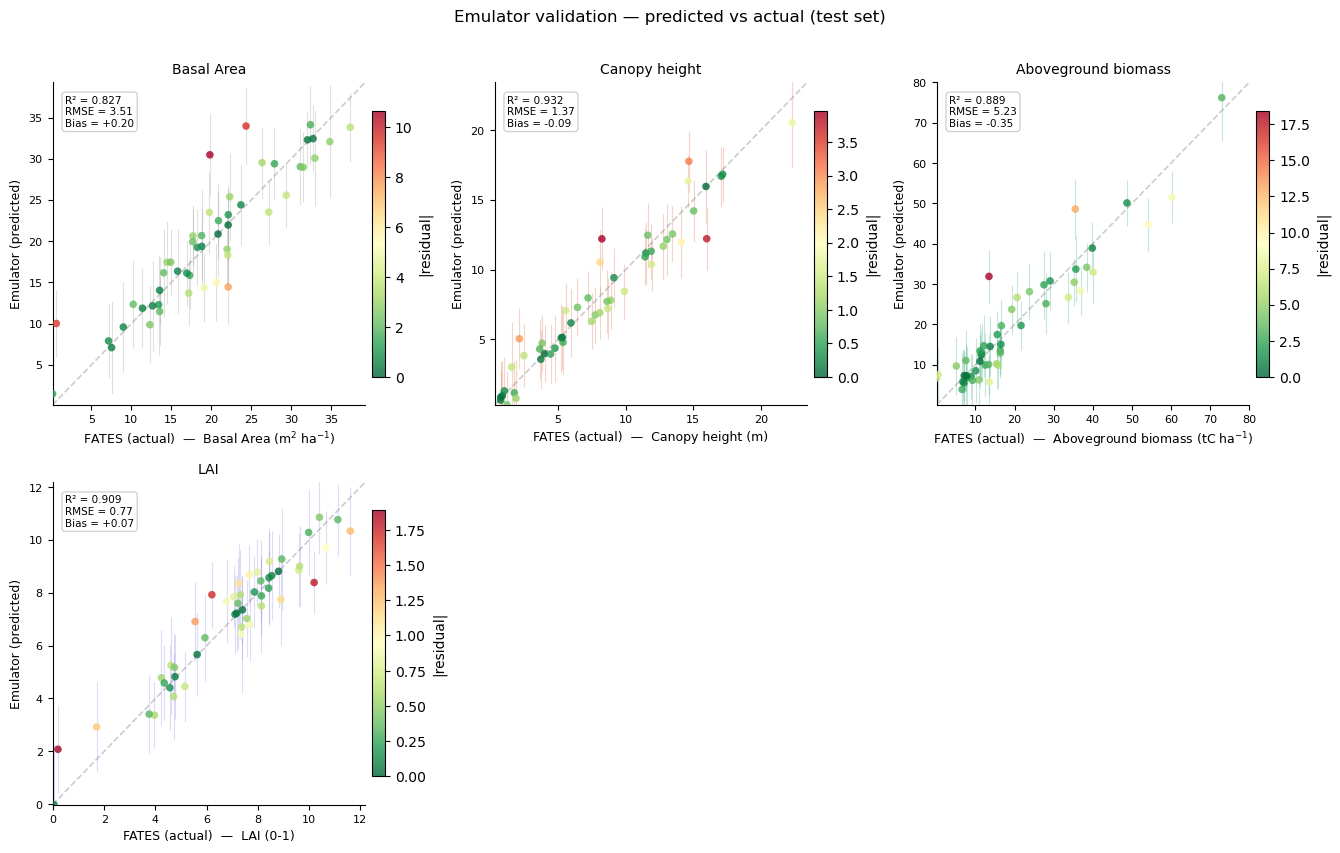

In [17]:
plotting.plot_emulator_validation_grid(variables, actuals, pred_means, pred_stds, var_config)
plt.savefig(os.path.join(fig_dir, "emulator_validation_scatter.png"),
            dpi=200, bbox_inches="tight")

### Emulator-based sensitivity

In [18]:
sensitivity = {}
for variable in variables:
    emulator_name = f"{pft}_{variable}"
    model = em.TFEmulator(os.path.join(emulator_dir, emulator_name))
    sensitivity[variable] = em.sensitivity_analysis(model, lh_key.columns)
    sensitivity[variable].index = sensitivity[variable]['parameter']

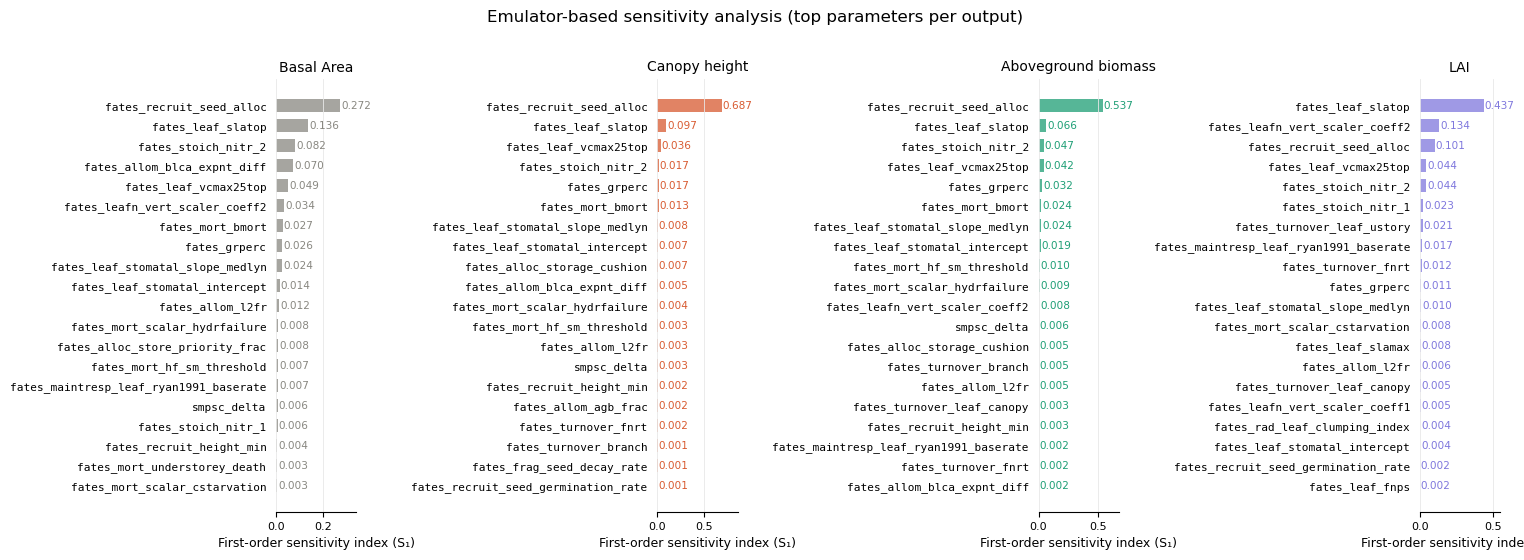

In [19]:
plotting.plot_sensitivity_bargraph(variables, sensitivity, var_config)
plt.savefig(os.path.join(fig_dir, "emulator_sensitivity.png"), dpi=200, bbox_inches="tight")

### Investigate Response Surfaces

In [31]:
response_variable = "biomass"
emulator_name = f"{pft}_{response_variable}"
model = em.TFEmulator(os.path.join(emulator_dir, emulator_name))

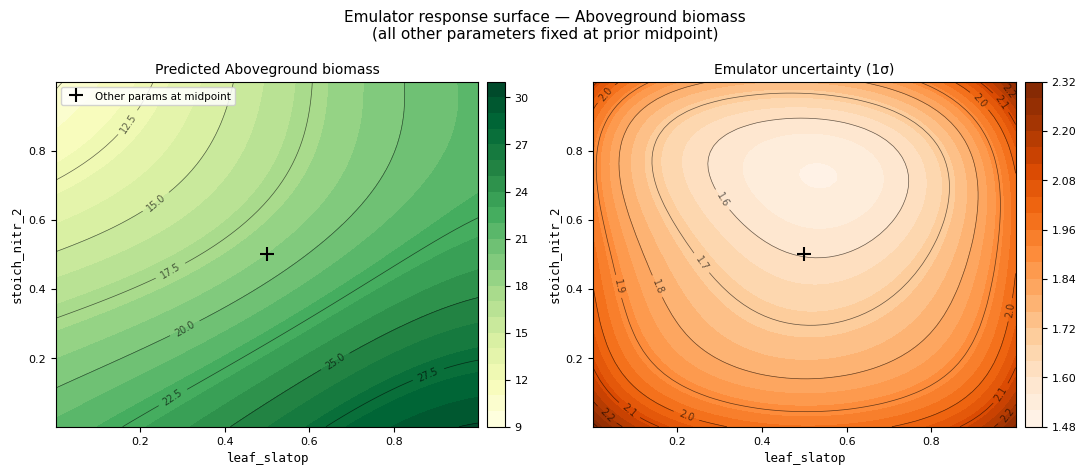

In [34]:
response_xparam = "fates_leaf_slatop"
response_yparam = "fates_stoich_nitr_2"

out_dict = em.generate_emulator_response_grid(lh_key, param_names,
                                              response_xparam, response_yparam,
                                              model)

plotting.plot_emulator_response_surface(out_dict,
                                        var_config[response_variable]['long_name'],
                                        response_xparam, response_yparam)
plt.savefig(os.path.join(fig_dir, "emulator_response_surface.png"), dpi=200, bbox_inches="tight")

## Calibration

In [35]:
sample_size = 1e4
implaus_tol = 1.0
min_implaus = 0.5
sens_tol = 0.1

variables = ['basal_area', 'height', 'biomass', 'LAI']

obs_mean = obs_ds.sel(type='mean')
obs_std = obs_ds.sel(type='std')

calibration_vars = [f"{pft}_{variable}" for variable in variables]
targets = [obs_mean[v].values for v in variables]
sds = [obs_std[v].values for v in variables]

emulators = em.load_emulators(emulator_dir, calibration_vars, [])

In [36]:
# Parameters for x, y, z axes
xparam = "fates_leaf_vcmax25top"
yparam = "fates_recruit_seed_alloc"
zparam = "fates_leaf_slatop"

In [37]:
sample = get_random_params(len(param_names), int(float(sample_size)))
df = pd.DataFrame(sample)
df.columns = param_names

In [39]:
for i, variable in enumerate(variables):
    y_pred, y_var = em.chunked_emulation(emulators[i], sample)
    implaus = em.implausibility_metric(y_pred, targets[i], y_var, sds[i] ** 2)
    df[calibration_vars[i]] = y_pred
    df[f"{calibration_vars[i]}_implaus"] = implaus

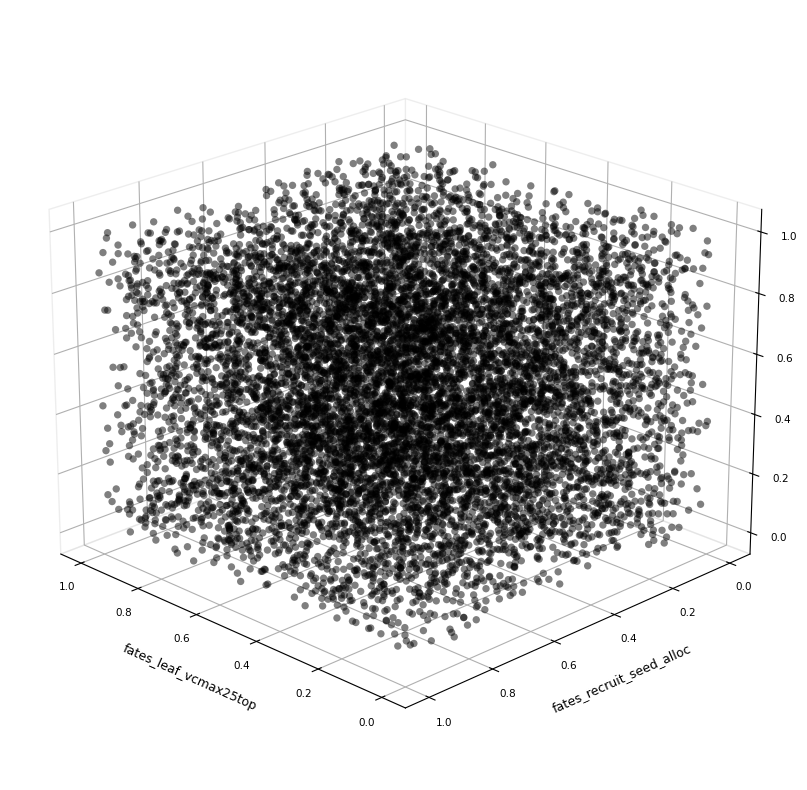

In [40]:
plotting.plot_3d_space(df, xparam, yparam, zparam, None, None, None, implaus_tol, subset=False)
plt.savefig(os.path.join(fig_dir, "hm_parameter_space_3d_unconstrained.png"), dpi=200, bbox_inches="tight")

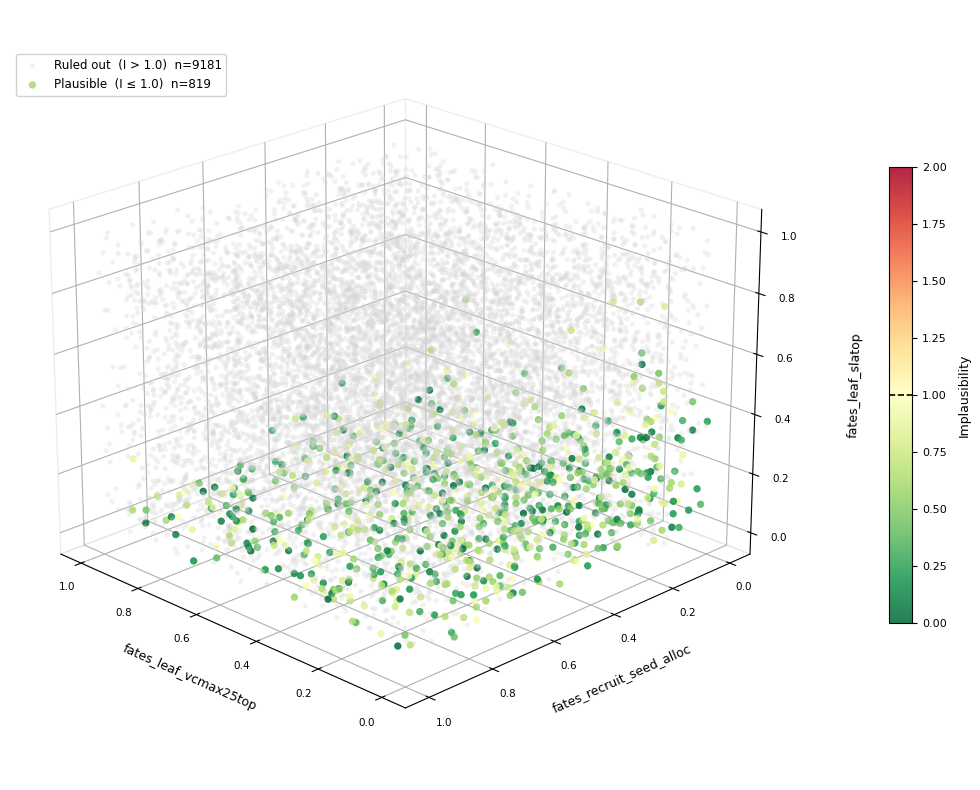

In [41]:
variable = 'black_spruce_LAI'
implausibility = df[f'{variable}_implaus']
accepted = df[f'{variable}_implaus'] <= implaus_tol
rejected = ~accepted

plotting.plot_3d_space(df, xparam, yparam, zparam, accepted, rejected, implausibility, implaus_tol)
plt.savefig(os.path.join(fig_dir, "hm_parameter_space_3d_LAI.png"), dpi=200, bbox_inches="tight")

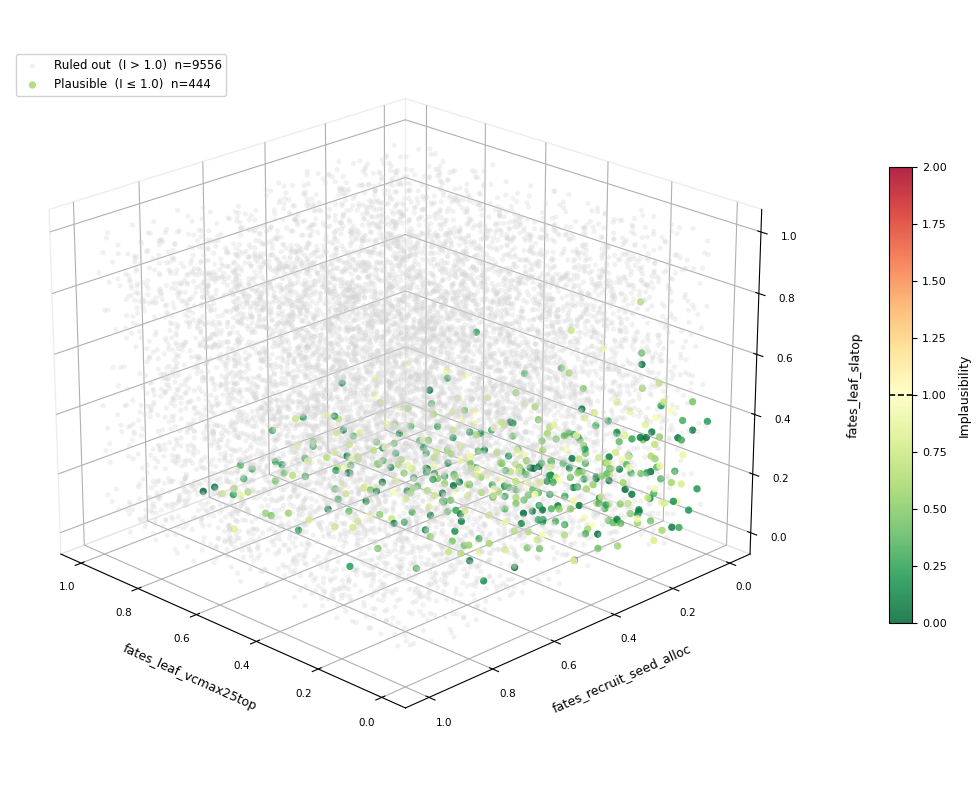

In [42]:
variable_1 = 'black_spruce_height'
variable_2 = 'black_spruce_LAI'
implausibility = df[f'{variable_2}_implaus']

accepted = (df[f'{variable_1}_implaus'] <= implaus_tol) & (df[f'{variable_2}_implaus'] <= implaus_tol)
rejected = ~accepted

plotting.plot_3d_space(df, xparam, yparam, zparam, accepted, rejected, implausibility, implaus_tol)
plt.savefig(os.path.join(fig_dir, "hm_parameter_space_3d_height.png"), dpi=200, bbox_inches="tight")

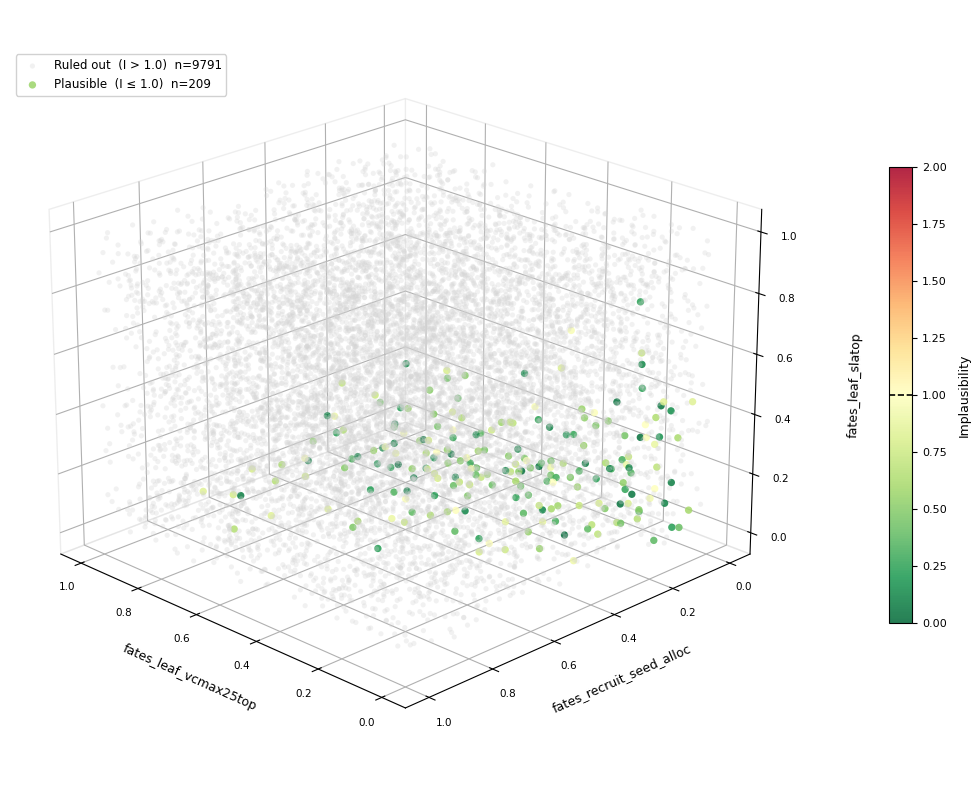

In [43]:
variable_1 = 'black_spruce_height'
variable_2 = 'black_spruce_LAI'
variable_3 = 'black_spruce_biomass'
implausibility = df[f'{variable_3}_implaus']

accepted = (df[f'{variable_1}_implaus'] <= implaus_tol) & (df[f'{variable_2}_implaus'] <= implaus_tol) & (df[f'{variable_3}_implaus'] <= implaus_tol)
rejected = ~accepted

plotting.plot_3d_space(df, xparam, yparam, zparam, accepted, rejected, implausibility, implaus_tol)
plt.savefig(os.path.join(fig_dir, "hm_parameter_space_3d_biomass.png"), dpi=200, bbox_inches="tight")

### Sensitivity

In [44]:
sample_df, sens_df = em.emulate_analyze(emulators, calibration_vars,
                                        targets, sds, param_names,
                                        update_pars=None,
                                        sample_size=sample_size)

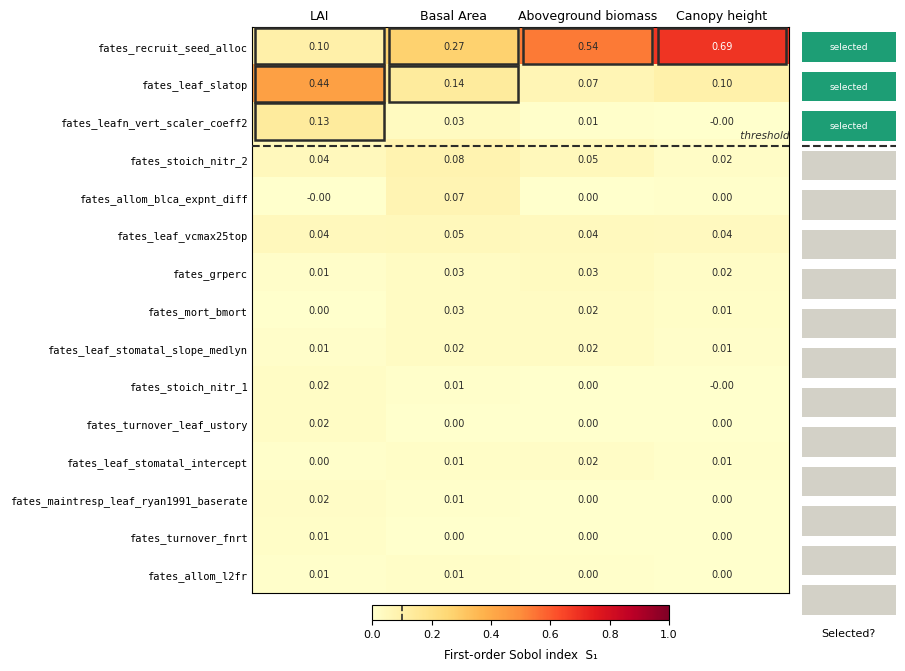

In [53]:
plotting.plot_sensitivity_table(calibration_vars, sens_df, var_config, 'black_spruce')
plt.savefig(os.path.join(fig_dir, "calibration_table.png"), dpi=200, bbox_inches="tight")

### Calibration

In [ ]:
param_list_name = "param_list_sci.1.81.1_api.38.0.0_nwt_jan2026.xls"
param_list_file = os.path.join(param_dir, param_list_name)
param_dat = paramgen.get_param_dictionary(param_list_file)

fates_param_name = "fates_params_api40_nwt_update_agb.nc"
default_param_data = xr.open_dataset(os.path.join(param_dir, fates_param_name), decode_timedelta=False)

jags_params = ['fates_leafn_vert_scaler_coeff1', 'fates_leafn_vert_scaler_coeff2']

In [ ]:
default_df = paramgen.get_default_normalized_param_values(param_names, param_dat, default_param_data, jags_params,
                                                          pft=1)
default_values = default_df.iloc[0]

In [ ]:
sample_size = 1e4
implaus_tol = 1.0
min_implaus = 0.5
sens_tol = 0.1

variables = ["basal_area", "biomass", "LAI", "height"]

obs_mean = obs_ds.sel(type='mean')
obs_std = obs_ds.sel(type='std')

calibration_vars = [f"{pft}_{variable}" for variable in variables]
targets = [obs_mean[v].values for v in variables]
sds = [obs_std[v].values for v in variables]

emulators = em.load_emulators(emulator_dir, calibration_vars, [])

In [ ]:
params_fix = ['fates_recruit_seed_germination_rate',
 'fates_recruit_height_min',
 'fates_allom_l2fr',
 'fates_turnover_leaf_canopy',
 'fates_leaf_slamax',
 'fates_turnover_branch',
 'fates_allom_fnrt_prof_a',
 'fates_mort_hf_sm_threshold',
 'fates_nonhydro_smpso',
 'fates_allom_agb_frac',
 'fates_rad_leaf_xl',
 'fates_cohort_size_fusion_tol',
 'fates_maintresp_reduction_curvature',
 'fates_maintresp_reduction_intercept',
 'fates_maintresp_reduction_upthresh',
 'fates_allom_h2cd1',
 'fates_turb_displar',
 'fates_recruit_init_density']

default_vals = default_values[params_fix]

In [ ]:
iteration = 0
update_pars = None

In [ ]:
iteration += 1
sample_df, sens_df = em.emulate_analyze(emulators, calibration_vars,
                                        targets, sds, param_names,
                                        update_pars=update_pars,
                                        default_vals=default_vals,
                                        sample_size=sample_size)

In [ ]:
sample_df.to_csv(os.path.join(top_dir, 'mc_calibration_workflow',
                              f'sample_df_iter_{iteration}.csv'))

In [ ]:
sub_df, best_sample = em.find_best_sample(sample_df, calibration_vars, implaus_tol)
sensitive_pars = em.find_sensitive_parameters(sens_df, calibration_vars,
                                              sens_tol=sens_tol)

In [ ]:
if em.decision_gate(sub_df, iteration, sensitive_pars, min_implaus=0.5,
                    verbose=False):
    print(f'Fixing parameters: {sensitive_pars}')
    update_pars = em.get_update_pars(update_pars, best_sample[sensitive_pars])
else:
    print("Calibration finished")

#### Investigate

In [54]:
out_dir = os.path.join(top_dir, 'mc_calibration_workflow')
files = sorted([os.path.join(out_dir, f) for f in os.listdir(out_dir) if f.endswith('.csv')])

dat_array = []
for i, file in enumerate(files):
    dat = pd.read_csv(file, index_col=[0])
    dat['iteration'] = i
    dat_array.append(dat)
dat = pd.concat(dat_array, ignore_index=True)

In [55]:
cols = calibration_vars + ['iteration']
results_df = dat[cols]

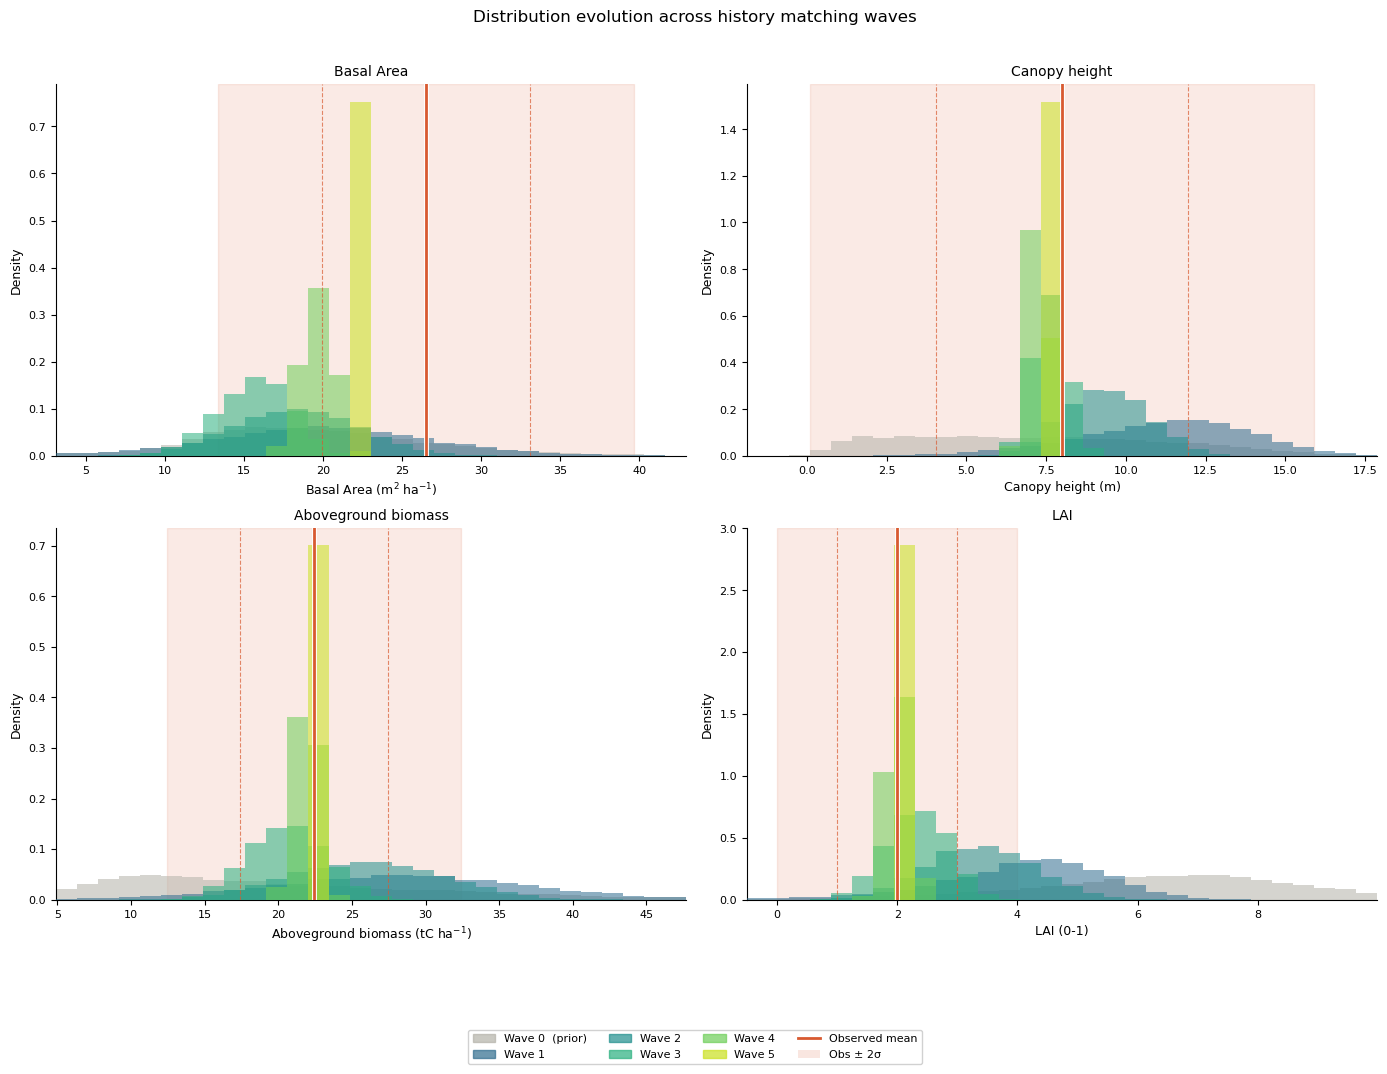

In [58]:
plotting.plot_calibration_distro(results_df, calibration_vars, obs_mean, obs_std, pft, var_config)
plt.savefig(os.path.join(fig_dir, "calibration_workflow.png"), dpi=200, bbox_inches="tight")